#### **Goal**: Here we use the unique hourly PDFs obtained during stochastic modelling phase for the stochastic optimization process

In [ ]:
!pip install mip

In [ ]:
import numpy as np
from scipy.stats import norm, weibull_min, beta
from scipy.special import gamma
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [ ]:
# File path where the dictionary is saved
file_path = "scenario_demand_data_2020.pickle"
file_path_a = "scenario_price_data_2020.pickle"
file_path_b = "scenario_solar_data_2020.pickle" # Actually the median value computed and not the mean

# Load the dictionary from the file
with open(file_path, 'rb') as file:
    forecast_demand = pickle.load(file)

with open(file_path_a, 'rb') as file:
    forecast_price = pickle.load(file)

with open(file_path_b, 'rb') as file:
    forecast_solar = pickle.load(file)

In [ ]:
forecast_demand

,Demand,prediction
Date,,
2020-01-15 00:00:00,3.597103,3.739111
2020-01-15 01:00:00,3.367257,3.524795
2020-01-15 02:00:00,3.179085,3.351040
2020-01-15 03:00:00,3.129225,3.301972
2020-01-15 04:00:00,3.184392,3.301972
2020-01-15 05:00:00,3.388288,3.466638
2020-01-15 06:00:00,3.713403,3.875238
2020-01-15 07:00:00,3.934797,4.331786
2020-01-15 08:00:00,4.045363,4.595048


In [ ]:
# Filling the forecast solar dataframe

index = pd.date_range(start='2020-01-15 06:00:00', end='2020-01-15 19:00:00', freq='h')
df = pd.DataFrame(forecast_solar, index=index)

# Create a complete time range for the day
full_index = pd.date_range(start='2020-01-15 00:00:00', end='2020-01-15 23:00:00', freq='h')

# Merge the original DataFrame with the complete time range, filling missing values with zeros
forecast_solar = df.reindex(full_index, fill_value=0)

In [ ]:
forecast_solar

,GHI,prediction
2020-01-15 00:00:00,0,0.000000
2020-01-15 01:00:00,0,0.000000
2020-01-15 02:00:00,0,0.000000
2020-01-15 03:00:00,0,0.000000
2020-01-15 04:00:00,0,0.000000
2020-01-15 05:00:00,0,0.000000
2020-01-15 06:00:00,101,88.854050
2020-01-15 07:00:00,230,285.611267
2020-01-15 08:00:00,475,415.960175
2020-01-15 09:00:00,642,533.398254


##### 1. Scenario Generation

In [ ]:
import numpy as np
from scipy.stats import norm, beta, gamma, lognorm, rayleigh, skewnorm, loggamma, cauchy, logistic, weibull_min

class scen_gen:
  def __init__(self, sample_size, time_period, solar_number, load_number, number_electricity_prices):
    self.sample_size = sample_size
    self.time_period = time_period
    self.solar_number = solar_number                                            # Indicating total number of solar generators in the power system (and corresponding number of random variables)
    self.load_number = load_number                                              # Indicating total number of load buses(or clusters) in the power system (and corresponding number of random variables)
    self.number_electricity_price = number_electricity_prices                   # Indicating only 1 utility company interfacing with the distribution network (and corresponding number of random variable)
    self.total_random_variables = self.solar_number + self.load_number + self.number_electricity_price    # Total number of random variables.

  def load_scen_gen(self, load_data):
      Load_Power = [None] * self.time_period
      shape = np.zeros((self.time_period, self.load_number))
      loc = np.zeros((self.time_period, self.load_number))
      scale = np.zeros((self.time_period, self.load_number))

      for t in range(self.time_period):
          pdf_data = load_data[t]
          q = np.random.rand(self.sample_size, self.load_number)
          # Set seed for reproducibility
          np.random.seed(000)

          # Point forecast
          demand_forecast = forecast_demand['prediction'][t]

          if 'lognorm_scale' in pdf_data:
              shape[t, :] = pdf_data['lognorm_shape']
              loc[t, :] = pdf_data['lognorm_loc']
              scale[t, :] = pdf_data['lognorm_scale']
              r_samples = lognorm.ppf(q, s = shape[t, :], loc=loc[t, :], scale=scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = demand_forecast + r_samples

          elif 'norm_scale' in pdf_data:
              loc[t, :] = pdf_data['norm_loc']
              scale[t, :] = pdf_data['norm_scale']
              r_samples = norm.ppf(q, loc=loc[t, :], scale=scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = demand_forecast + r_samples

          elif 'skewnorm_scale' in pdf_data:
              shape[t, :] = pdf_data['skewnorm_shape']
              loc[t, :] = pdf_data['skewnorm_loc']
              scale[t, :] = pdf_data['skewnorm_scale']
              r_samples = skewnorm.ppf(q, a = shape[t, :], loc=loc[t, :], scale=scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = demand_forecast + r_samples

          elif 'loggamma_scale' in pdf_data:
              shape[t, :] = pdf_data['loggamma_shape']
              loc[t, :] = pdf_data['loggamma_loc']
              scale[t, :] = pdf_data['loggamma_scale']
              r_samples = loggamma.ppf(q, c = shape[t, :], loc= loc[t, :], scale= scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = demand_forecast + r_samples

          else:
              raise ValueError(f"Unsupported PDF detected for hour {t}")

          Load_Power[t] = samples * 0.5 # samples * 0.5

      return Load_Power

  def electricity_price_scen_gen(self, electricity_price_data):
      Electricity_prices = [None] * self.time_period
      shape = np.zeros((self.time_period, self.load_number))
      loc = np.zeros((self.time_period, self.load_number))
      scale = np.zeros((self.time_period, self.load_number))

      for t in range(self.time_period):
          pdf_data = electricity_price_data[t]
          q = np.random.rand(self.sample_size, self.load_number)
          # Set seed for reproducibility
          np.random.seed(222)

          # Point forecast
          price_forecast = forecast_price['prediction'][t]

          if 'gamma_scale' in pdf_data:
              shape[t, :] = pdf_data['gamma_shape']
              loc[t, :] = pdf_data['gamma_loc']
              scale[t, :] = pdf_data['gamma_scale']
              r_samples = gamma.ppf(q, a = shape[t, :], loc= loc[t, :], scale= scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = price_forecast + r_samples

          elif 'skewnorm_scale' in pdf_data:
              shape[t, :] = pdf_data['skewnorm_shape']
              loc[t, :] = pdf_data['skewnorm_loc']
              scale[t, :] = pdf_data['skewnorm_scale']
              r_samples = skewnorm.ppf(q, a = shape[t, :], loc=loc[t, :], scale=scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = price_forecast + r_samples

          elif 'lognorm_scale' in pdf_data:
              shape[t, :] = pdf_data['lognorm_shape']
              loc[t, :] = pdf_data['lognorm_loc']
              scale[t, :] = pdf_data['lognorm_scale']
              r_samples = lognorm.ppf(q, s = shape[t, :], loc=loc[t, :], scale=scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = price_forecast + r_samples

          else:
              raise ValueError(f"Unsupported PDF detected for hour {t}")

          Electricity_prices[t] = samples

      return Electricity_prices

  def solar_power_scen_gen(self, solar_irradiance_data, S_params, amb_temp):
      solar_irradiance = [None] * self.time_period
      shape = np.zeros((self.time_period, self.solar_number))
      shape1 = np.zeros((self.time_period, self.solar_number))
      shape2 = np.zeros((self.time_period, self.solar_number))
      loc = np.zeros((self.time_period, self.solar_number))
      scale = np.zeros((self.time_period, self.solar_number))

      Nominal_temp = S_params[0]   # N_OT (nominal operating temperature of solar cell) (degree celsius)
      Temp_coef = S_params[1]      # K_i (current temperature coefficient of PV module) (A/degree celsius)
      SCC = S_params[2]            # I_sc (short circuit current)
      V_temp_coef = S_params[3]    # K_v (voltage temperature coefficient of PV module) (V/degree celsius)
      V_oc = S_params[4]           # Open circuit voltage (V)
      V_mpp = S_params[5]          # Maximum power voltage (V)
      I_mpp = S_params[6]          # Maximum power current (A)

      for t in range(self.time_period):
          pdf_data = solar_irradiance_data[t]
          q = np.random.rand(self.sample_size, self.solar_number)       # Change to Quasi-random sampling
          # Set seed for reproducibility
          np.random.seed(555)

          # Point forecast
          solar_forecast = forecast_solar['prediction'][t]

          if 'logistic_scale' in pdf_data:
              loc[t, :] = pdf_data['logistic_loc']
              scale[t, :] = pdf_data['logistic_scale']
              r_samples = logistic.ppf(q, loc=loc[t, :], scale=scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = solar_forecast + r_samples

          elif 'skewnorm_scale' in pdf_data:
              shape[t, :] = pdf_data['skewnorm_shape']
              loc[t, :] = pdf_data['skewnorm_loc']
              scale[t, :] = pdf_data['skewnorm_scale']
              r_samples = skewnorm.ppf(q, a = shape[t, :], loc=loc[t, :], scale=scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = solar_forecast + r_samples

          elif 'gamma_scale' in pdf_data:
              shape[t, :] = pdf_data['gamma_shape']
              loc[t, :] = pdf_data['gamma_loc']
              scale[t, :] = pdf_data['gamma_scale']
              r_samples = gamma.ppf(q, a = shape[t, :], loc= loc[t, :], scale= scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = solar_forecast + r_samples

          elif 'weibull_scale' in pdf_data:
              shape[t, :] = pdf_data['weibull_shape']
              loc[t, :] = pdf_data['weibull_loc']
              scale[t, :] = pdf_data['weibull_scale']
              r_samples = weibull_min.ppf(q, c = shape[t, :], loc= loc[t, :], scale= scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = solar_forecast + r_samples

          elif 'rayleigh_scale' in pdf_data:
              loc[t, :] = pdf_data['rayleigh_loc']
              scale[t, :] = pdf_data['rayleigh_scale']
              r_samples = rayleigh.ppf(q, loc=loc[t, :], scale=scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = solar_forecast + r_samples

          elif 'beta_scale' in pdf_data:
              shape1[t, :] = pdf_data['beta_shape1']
              shape2[t, :] = pdf_data['beta_shape2']
              loc[t, :] = pdf_data['beta_loc']
              scale[t, :] = pdf_data['beta_scale']
              r_samples = beta.ppf(q, a = shape1[t, :], b = shape2[t, :], loc= loc[t, :], scale=scale[t, :])

              # Generating random samples based on forecast and (error data -> r_samples)
              samples = solar_forecast + r_samples

          else:
              raise ValueError(f"Unsupported PDF detected for hour {t}")

          solar_irradiance[t] = samples/1000    # Normalize to kW

      # Conversion of solar irradiation to solar power
      # 1.
      cell_temp = [None] * self.time_period
      for t in range(self.time_period):
        cell_temp[t] = np.zeros((self.sample_size, self.solar_number))
        for i in range(self.solar_number):
          for j in range(self.sample_size):
            cell_temp[t][j, i] = amb_temp[t] + (solar_irradiance[t][j, i] * ((Nominal_temp - 20)/0.8))

      # 2.
      solar_voltage = [None] * self.time_period
      for t in range(self.time_period):
        solar_voltage[t] = np.zeros((self.sample_size, self.solar_number))
        for i in range(self.solar_number):
          for j in range(self.sample_size):
            solar_voltage[t][j, i] = V_oc - (V_temp_coef * cell_temp[t][j, i])

      # 3.
      solar_current = [None] * self.time_period
      for t in range(self.time_period):
        solar_current[t] = np.zeros((self.sample_size, self.solar_number))
        for i in range(self.solar_number):
          for j in range(self.sample_size):
            solar_current[t][j, i] = solar_irradiance[t][j, i] * (SCC + Temp_coef * (cell_temp[t][j, i] - 25))

      # 4.
      FF = (V_mpp * I_mpp)/(V_oc * SCC)
      Npv = 50    # 50 pieces of solar panels

      # 5.
      Solar_Power = [None] * self.time_period
      for t in range(self.time_period):
        Solar_Power[t] = np.zeros((self.sample_size, self.solar_number))
        for i in range(self.solar_number):
          for j in range(self.sample_size):
            Solar_Power[t][j, i] = Npv * FF * solar_voltage[t][j, i] * solar_current[t][j, i]

      return Solar_Power

##### 2. Scenario Reduction

In [ ]:
class scen_red:
  def __init__(self, generated_samples, sample_size, number_desired_scenarios, time_period, load_number, solar_number, number_electricity_prices):
    self.generated_samples_copy = generated_samples.copy()
    self.sample_size = sample_size
    self.reduced_sample_size = number_desired_scenarios
    self.time_period = time_period
    self.load_number = load_number
    self.solar_number = solar_number
    self.number_electricity_price = number_electricity_prices

  def reduced_scen(self):
    # Initialize the probability matrix
    prob_matrix = np.ones(self.sample_size) / self.sample_size

    while self.sample_size > self.reduced_sample_size:
        Distance_matrix = []
        min_distance = []
        Index_min = []
        Index_min_scenario = []
        prob_multiply_min_distance = []
        min_prob_multiply_min_distance = []
        Index_min_prob_multiply_min_distance = []
        closest_scenarios = []
        choosen_scenario = []
        deleted_scenario = []

        # Determine the Initial Distance Matrix
        for t in range(self.time_period):
            Distance_matrix_t = np.zeros((self.sample_size, self.sample_size))
            for i in range(self.sample_size):
                for j in range(self.sample_size):
                    Distance_matrix_t[i, j] = np.linalg.norm(self.generated_samples_copy[t][i] - self.generated_samples_copy[t][j])
            Distance_matrix.append(Distance_matrix_t)


        # Determine the minimum values in each column of D without considering zeros
        for t in range(self.time_period):
            min_distance_t = []  # Initialize as an empty list for this t
            A = Distance_matrix[t]

            for i in range(self.sample_size):
                B = A[:, i]
                valid_indices = np.where(B > 0) # This is where the elements of self-distance d_ii is excluded (d_ii is 0)
                min_distance_t_i = np.min(B[valid_indices])
                min_distance_t.append(min_distance_t_i)

            min_distance.append(min_distance_t)

            index_min_t = []  # Initialize as an empty list for this t
            for i in range(self.sample_size):
                index_min_t_i = np.where(A[:, i] == min_distance_t[i])[0]
                index_min_t.append(index_min_t_i)

            Index_min.append(index_min_t)

            index_min_scenario_t = []  # Initialize as an empty list for this t
            for i in range(self.sample_size):
                index_min_scenario_t.append([Index_min[t][i], i])

            Index_min_scenario.append(index_min_scenario_t)

            prob_multiply_min_distance_t = min_distance_t * prob_matrix
            prob_multiply_min_distance.append(prob_multiply_min_distance_t)

            min_prob_multiply_min_distance_t = np.min(prob_multiply_min_distance_t)
            min_prob_multiply_min_distance.append(min_prob_multiply_min_distance_t)

            index_min_prob_multiply_min_distance_t = np.where(prob_multiply_min_distance_t == min_prob_multiply_min_distance_t)

            closest_scenarios_t = Index_min_scenario[t][index_min_prob_multiply_min_distance_t[0][0]]
            closest_scenarios.append(closest_scenarios_t)

            if prob_matrix[closest_scenarios_t[0][0]] > prob_matrix[closest_scenarios_t[1]]:
                choosen_scenario_t = closest_scenarios_t[0]
                deleted_scenario_t = closest_scenarios_t[1]
            else:
                choosen_scenario_t = closest_scenarios_t[1]
                deleted_scenario_t = closest_scenarios_t[0]

            self.generated_samples_copy[t] = np.delete(self.generated_samples_copy[t], deleted_scenario_t, axis=0)

        prob_matrix[choosen_scenario_t] += prob_matrix[deleted_scenario_t]
        prob_matrix = np.delete(prob_matrix, deleted_scenario_t)
        self.sample_size -= 1

    # Determine the load power, wind power, PV power, and electricity prices
    reduced_generated_samples = self.generated_samples_copy
    Reduced_Load_Power, Reduced_Solar_Power, Reduced_Electricity_prices = [], [], []

    for t in range(self.time_period):
      Reduced_Load_Power.append(reduced_generated_samples[t][:, :self.load_number])
      Reduced_Solar_Power.append(np.abs(reduced_generated_samples[t][:, self.load_number:self.load_number + self.solar_number]))
      Reduced_Electricity_prices.append(reduced_generated_samples[t][:, self.load_number + self.solar_number:])

    return reduced_generated_samples, prob_matrix, Reduced_Load_Power, Reduced_Solar_Power, Reduced_Electricity_prices

##### 3. Parameter definitions I

In [ ]:
import pickle

# File path where the dictionary is saved
file_path_1 = "solarerror_data_unique.pickle"
file_path_2 = "loaderror_data_unique.pickle"
file_path_3 = "priceerror_data_unique.pickle"

# Load the dictionary from the file
with open(file_path_1, 'rb') as file_a:
    solar_data = pickle.load(file_a)

with open(file_path_2, 'rb') as file_b:
    load_data = pickle.load(file_b)

with open(file_path_3, 'rb') as file_c:
    price_data = pickle.load(file_c)

In [ ]:
# Parameter definitions

time_period = 24
sample_size = 150
number_desired_scenarios = 10
solar_number = 1
load_number = 1
number_electricity_prices = 1


# Extract the data
load_data = load_data
electricity_price_data = price_data
solar_irradiance_data = solar_data

##### 4. Scenario Generation and Reduction Implementation

In [ ]:
import time

# Start the timer
# Record the start time
start_time = time.time()

# Solar power data
Nominal_temp = 43     # N_OT (nominal operating temperature of solar cell) (degree celsius)
Temp_coef = 0.00122   # K_i (current temperature coefficient of PV module) (A/degree celsius)
SCC = 5.32            # I_sc (short circuit current)
V_temp_coef = 0.0144  # K_v (voltage temperature coefficient of PV module) (V/degree celsius)
V_oc = 21.98          # Open circuit voltage (V)
V_mpp = 17.32         # Maximum power voltage (V)
I_mpp = 4.76          # Maximum power current (A)

S_params = [Nominal_temp, Temp_coef, SCC, V_temp_coef, V_oc, V_mpp, I_mpp]

# Import ambient temperature data
data_temp = pd.read_csv('Ambient_temp_2020.csv')
amb_temp = data_temp['Temperature']

# Scenario generation for all random variables
gen_scenarios = scen_gen(sample_size, time_period, solar_number, load_number, number_electricity_prices)

Load_Power = gen_scenarios.load_scen_gen(load_data)

Solar_Power = gen_scenarios.solar_power_scen_gen(solar_irradiance_data, S_params, amb_temp)

Electricity_prices = gen_scenarios.electricity_price_scen_gen(electricity_price_data)

# Compiled generated samples for all random variables (per hour)
generated_samples = [np.concatenate((Load_Power[t], Solar_Power[t], Electricity_prices[t]), axis = 1) for t in range(time_period)]

<ipython-input-21-df26304e5f5a>:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  demand_forecast = forecast_demand['prediction'][t]
<ipython-input-21-df26304e5f5a>:142: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  solar_forecast = forecast_solar['prediction'][t]
<ipython-input-21-df26304e5f5a>:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  price_forecast = forecast_price['prediction'][t]


In [ ]:
# Scenario reduction for all random variables
reduce_scenarios = scen_red(generated_samples, sample_size, number_desired_scenarios, time_period, load_number, solar_number, number_electricity_prices)
reduced_generated_samples, prob_matrix, Reduced_Load_Power, Reduced_Solar_Power, Reduced_Electricity_prices = reduce_scenarios.reduced_scen()

# Compiled reduced samples for all random variables (per hour)
reduced_samples = reduced_generated_samples
probability_matrix = prob_matrix

<ipython-input-22-cf21f1fc2df1>:82: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prob_matrix[choosen_scenario_t] += prob_matrix[deleted_scenario_t]


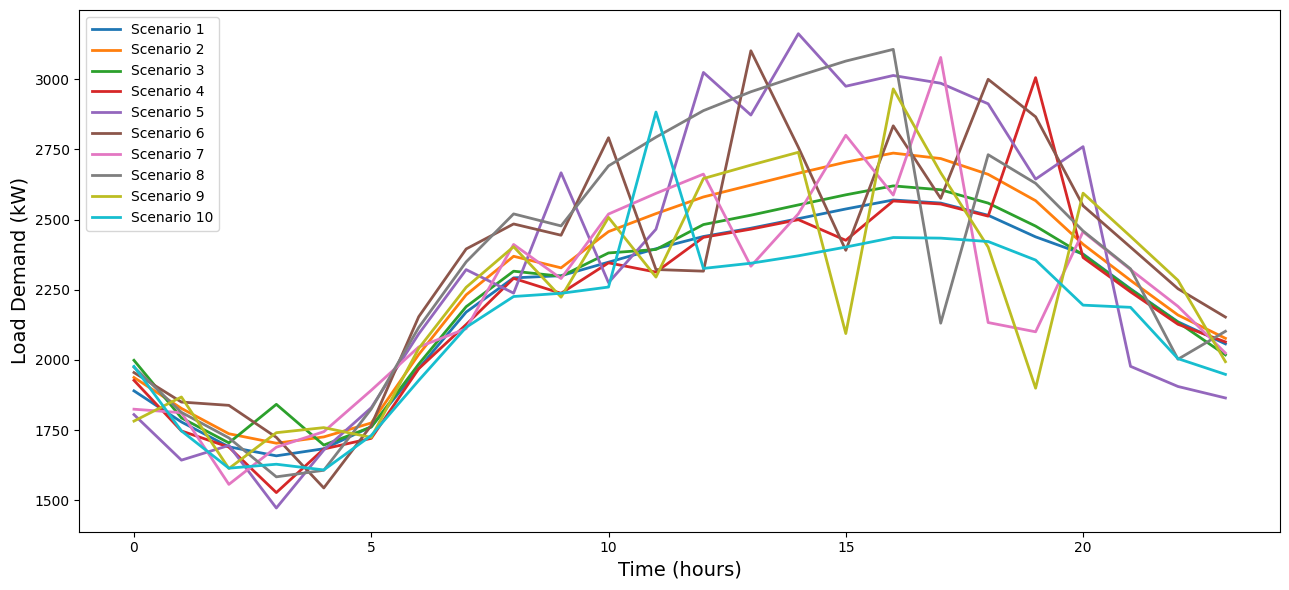

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize lists to store the data for plotting
Time = np.arange(len(Reduced_Load_Power))  # Time from 0 to 24
scenarios = np.hstack([d.flatten() for d in Reduced_Load_Power])  # Flatten each array into a 1D array of load values

# Set up the figure size for horizontal expansion (for publication quality)
plt.figure(figsize=(13, 6))  # Make the plot wider

for i in range(10):  # 10 scenarios
    load_scenario = [Reduced_Load_Power[t][i][0] * 1000 for t in range(len(Reduced_Load_Power))]  # Get the ith scenario across all time periods
    plt.plot(Time, load_scenario, label=f'Scenario {i+1}', linewidth=2)

# Add labels and title
plt.xlabel('Time (hours)', fontsize=14)
plt.ylabel('Load Demand (kW)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)

# Show the plot
plt.tight_layout()

# Save the plot as a high-resolution image for download
plt.savefig('load_demand_scenarios.png', dpi=300, bbox_inches='tight')

plt.show()

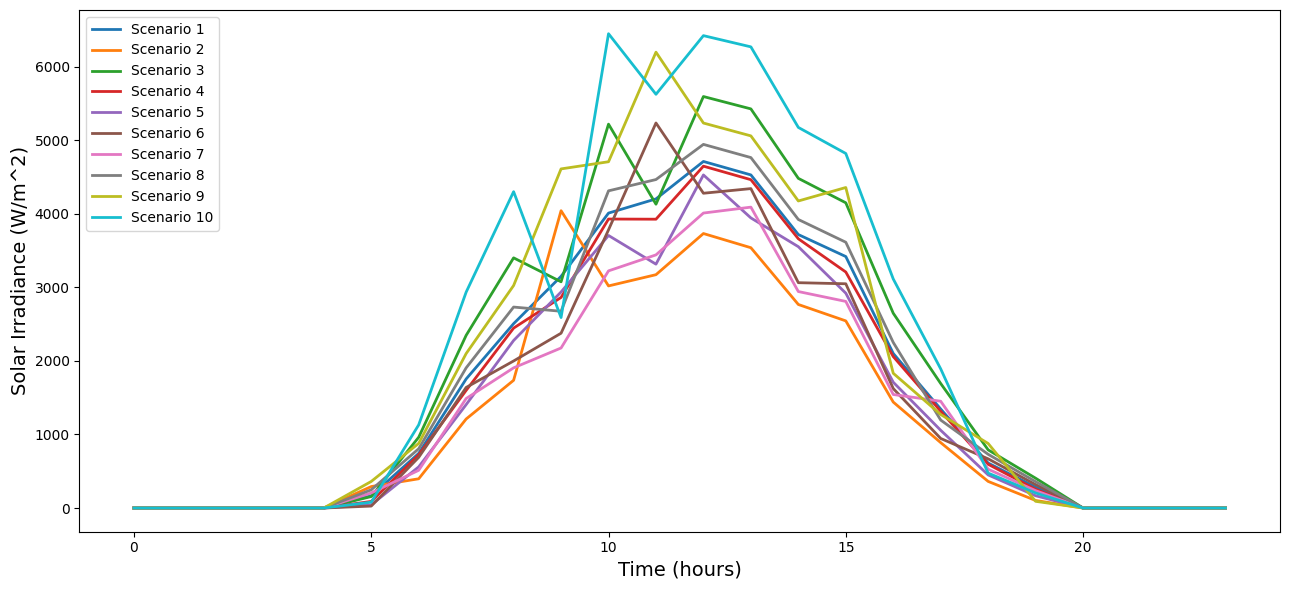

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize lists to store the data for plotting
Time = np.arange(len(Reduced_Solar_Power))  # Time from 0 to 24
scenarios = np.hstack([d.flatten() for d in Reduced_Solar_Power])  # Flatten each array into a 1D array of load values

# Set up the figure size for horizontal expansion (for publication quality)
plt.figure(figsize=(13, 6))  # Make the plot wider

for i in range(10):  # 10 scenarios
    solar_scenario = [Reduced_Solar_Power[t][i][0] for t in range(len(Reduced_Solar_Power))]  # Get the ith scenario across all time periods
    plt.plot(Time, solar_scenario, label=f'Scenario {i+1}', linewidth=2)

# Add labels and title
plt.xlabel('Time (hours)', fontsize=14)
plt.ylabel('Solar Irradiance (W/m^2)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)

# Show the plot
plt.tight_layout()

# Save the plot as a high-resolution image for download
plt.savefig('solar_irradiance_scenarios.png', dpi=300, bbox_inches='tight')

plt.show()

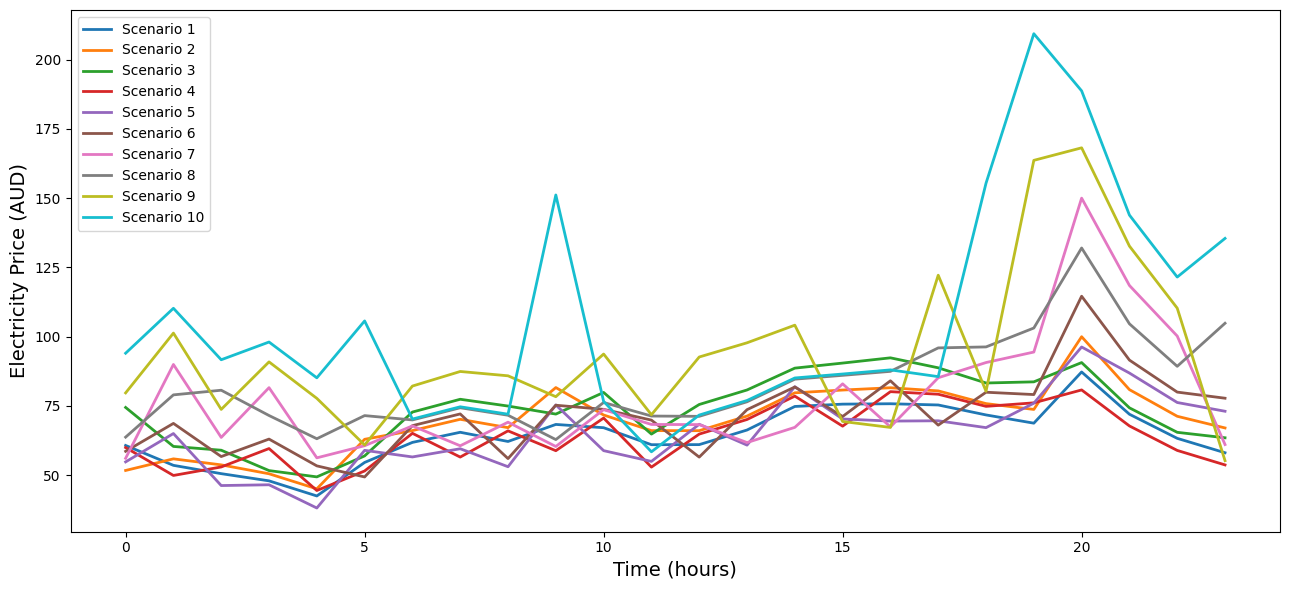

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize lists to store the data for plotting
Time = np.arange(len(Reduced_Electricity_prices))  # Time from 0 to 24
scenarios = np.hstack([d.flatten() for d in Reduced_Electricity_prices])  # Flatten each array into a 1D array of load values

# Set up the figure size for horizontal expansion (for publication quality)
plt.figure(figsize=(13, 6))  # Make the plot wider

for i in range(10):  # 10 scenarios
    price_scenario = [Reduced_Electricity_prices[t][i][0] for t in range(len(Reduced_Electricity_prices))]  # Get the ith scenario across all time periods
    plt.plot(Time, price_scenario, label=f'Scenario {i+1}', linewidth=2)

# Add labels and title
plt.xlabel('Time (hours)', fontsize=14)
plt.ylabel('Electricity Price (AUD)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)

# Show the plot
plt.tight_layout()

# Save the plot as a high-resolution image for download
plt.savefig('Electricity_price_scenarios.png', dpi=300, bbox_inches='tight')

plt.show()

##### 5. Transforming Reduced Scenarios (For Unit Commitment)

In [ ]:
original_data_1 = Reduced_Load_Power
original_data_2 = Reduced_Solar_Power
original_data_3 = Reduced_Electricity_prices

# Define the index for which you want to create new arrays
scenarios_dict_1 = {}
scenarios_dict_2 = {}
scenarios_dict_3 = {}

# Create a new array for the specified index
for index in range(number_desired_scenarios):
  scenarios_dict_1[index] = [arr[index][0] for arr in original_data_1]       # /1000 to normalize to GW
  scenarios_dict_2[index] = [arr[index][0] for arr in original_data_2]       # /1000 to normalize to GW
  scenarios_dict_3[index] = [arr[index][0] for arr in original_data_3]


all_load_demand_scen = [scenarios_dict_1[index] for index in range(number_desired_scenarios)]
all_pv_power_scen = [scenarios_dict_2[index] for index in range(number_desired_scenarios)]
all_tou_price_scen = [scenarios_dict_3[index] for index in range(number_desired_scenarios)]
all_probs_scen = list(probability_matrix)

##### 6. Unit Commitment Optimization

* Edit and make the computation for all scenarios.

In [ ]:
import numpy as np
from mip import Model, xsum, BINARY, CONTINUOUS, MINIMIZE, CBC, OptimizationStatus

class UnitCommitmentProblem:
    def __init__(self, time_run, num_units, min_up, min_down, init_prod_level, coef_a, coef_b, costs_start, costs_shut, min_outputs, \
                 max_outputs, ramp_up_rates, ramp_down_rates, battery_energy_min, battery_energy_max, batt_eff, grid_min, grid_max, \
                 all_pv_power_scen, all_load_demand_scen, all_tou_price_scen, all_probs_scen, num_scen, bess_coef, pv_omcosts):

        self.num_units = num_units
        self.coef_a = coef_a
        self.coef_b = coef_b
        self.costs_start = costs_start
        self.costs_shut = costs_shut
        self.min_outputs = min_outputs
        self.max_outputs = max_outputs
        self.ramp_up_rates = ramp_up_rates
        self.ramp_down_rates = ramp_down_rates
        self.min_up = min_up
        self.min_down = min_down
        self.init_prod_level = init_prod_level
        self.grid_min = grid_min
        self.grid_max = grid_max
        self.batt_eff_discharge = batt_eff
        self.batt_eff_charge = batt_eff
        self.battery_energy_min = battery_energy_min
        self.battery_energy_max = battery_energy_max
        self.battery_energy_init = 150
        self.battery_energy_end = 900
        self.rated_battery = 900
        self.charge_power_max = 100
        self.charge_power_min = 0
        self.discharge_power_max = 100
        self.discharge_power_min = 0
        self.pv_scenarios = all_pv_power_scen
        self.load_scenarios = all_load_demand_scen
        self.price_scenarios = all_tou_price_scen
        self.prob_scenarios = all_probs_scen
        self.num_scenarios = num_scen
        self.time_run = time_run

        self.besscoef = bess_coef
        self.pv_omcosts = pv_omcosts

    def solve(self):
    # Create a MIP model with the CBC solver
        model = Model(solver_name=CBC)
        robust = 0
        periods = [i for i in range(len(self.time_run))]
        firstPeriod = periods[0]
        lastPeriod = periods[-1]
        nextPeriod = {}
        for i in range(len(periods) - 1):
            nextPeriod[periods[i]] = periods[i+1]

        # Define variables
        # Variable 1: in_use[u,t,s] is true iff unit u is in production at period t in scenario s
        in_use = [[[model.add_var(var_type=BINARY) for u in range(self.num_units)] for t in periods] for s in range(self.num_scenarios)]

        # Variable 2: true if unit u is turned on at period t in scenario s
        turn_on = [[[model.add_var(var_type=BINARY) for u in range(self.num_units)] for t in periods] for s in range(self.num_scenarios)]

        # Variable 3: true if unit u is switched off at period t in scenario s
        turn_off = [[[model.add_var(var_type=BINARY) for u in range(self.num_units)] for t in periods] for s in range(self.num_scenarios)]

        # Variable 4: production of energy for unit u at period t in scenario s
        production = [[[model.add_var(var_type=CONTINUOUS) for u in range(self.num_units)] for t in periods] for s in range(self.num_scenarios)]

        # Variable 5: battery power (Es) in scenario s
        battery_energy = [[model.add_var(var_type=CONTINUOUS) for t in periods] for s in range(self.num_scenarios)]

        # Variable 6: battery soc (SoC) in scenario s
        soc = [[model.add_var(var_type=CONTINUOUS) for t in periods] for s in range(self.num_scenarios)]

        # Variable 7: battery charge and discharge in scenario s
        p_charge = [[model.add_var(var_type=CONTINUOUS) for t in periods] for s in range(self.num_scenarios)]
        p_discharge = [[model.add_var(var_type=CONTINUOUS) for t in periods] for s in range(self.num_scenarios)]

        # Variable 8: battery indicator for charge/discharge in scenario s
        ind_charge = [[model.add_var(var_type=BINARY) for t in periods] for s in range(self.num_scenarios)]
        ind_discharge = [[model.add_var(var_type=BINARY) for t in periods] for s in range(self.num_scenarios)]

        # Variable 9: grid power in scenario s
        grid_power = [[model.add_var(var_type=CONTINUOUS) for t in periods] for s in range(self.num_scenarios)]

        # Define Objectives
        expected_total_costs = 0

        for s in range(self.num_scenarios):
            variable_costs = xsum((self.coef_a[u] * in_use[s][t][u] + self.coef_b[u] * production[s][t][u]) for u in range(self.num_units) \
                                      for t in periods)
            startup_costs = xsum((self.costs_start[u] * turn_on[s][t][u]) for u in range(self.num_units) for t in periods)
            shutdown_costs = xsum((self.costs_shut[u] * turn_off[s][t][u]) for u in range(self.num_units) for t in periods)
            grid_power_costs = xsum((self.price_scenarios[s][t] * grid_power[s][t]) for t in periods)
            bess_degrad_costs = xsum(((self.besscoef * p_discharge[s][t]) + (self.besscoef * battery_energy[s][t]) + \
                                      (self.besscoef * p_charge[s][t])) for t in periods)
            pv_om_costs = xsum((self.pv_omcosts * self.pv_scenarios[s][t]) for t in periods)

            total_costs = variable_costs + startup_costs + shutdown_costs + grid_power_costs + bess_degrad_costs + pv_om_costs

            expected_total_costs += total_costs * self.prob_scenarios[s]

        model.objective = expected_total_costs

        # Define Constraints
        # Constraint 1: Battery indicator status constraints
        for s in range(self.num_scenarios):
            for t in periods:
                model += ind_charge[s][t] + ind_discharge[s][t] <= 1

        # Constraint 2: Battery energy (Es)
        # Initial state
        for s in range(self.num_scenarios):
            for t in periods:
                if t == firstPeriod:
                    model += battery_energy[s][t] == self.battery_energy_init
                    model += soc[s][t] == battery_energy[s][t] / self.rated_battery
                elif t == lastPeriod:
                    model += battery_energy[s][t] >= self.battery_energy_end
                    model += soc[s][t] == battery_energy[s][t] / self.rated_battery
        # Other states
        for s in range(self.num_scenarios):
            for t in periods:
                if t != lastPeriod:
                    model += battery_energy[s][nextPeriod[t]] == battery_energy[s][t] - (p_discharge[s][t] / self.batt_eff_discharge) + \
                                                                  (p_charge[s][t] * self.batt_eff_charge)  # Let delta_t = 1 hour
                    model += soc[s][nextPeriod[t]] == battery_energy[s][nextPeriod[t]] / self.rated_battery

        # Constraint 3: Battery power production (charge/discharge limits)
        for s in range(self.num_scenarios):
            for t in periods:
                model += p_charge[s][t] <= ind_charge[s][t] * self.charge_power_max
                model += p_charge[s][t] >= self.charge_power_min
                model += p_discharge[s][t] <= ind_discharge[s][t] * self.discharge_power_max
                model += p_discharge[s][t] >= self.discharge_power_min

        # Constraint 4: Battery's energy lb and ub
        for s in range(self.num_scenarios):
            for t in periods:
                model += battery_energy[s][t] <= self.battery_energy_max
                model += battery_energy[s][t] >= self.battery_energy_min

        # Constraint 5: Grid's power lb and ub
        for s in range(self.num_scenarios):
            for t in periods:
                model += grid_power[s][t] <= self.grid_max
                model += grid_power[s][t] >= self.grid_min

        # Bounds/Limits
        # Constraints 6: Generator's production bound
        for s in range(self.num_scenarios):
            for u in range(self.num_units):
                for t in periods:
                    model += production[s][t][u] <= self.max_outputs[u] * in_use[s][t][u]
                    model += production[s][t][u] >= self.min_outputs[u] * in_use[s][t][u]

        # Constraint 7: Initial state
        # If initial production is non-zero (greater than zero), then period #1 is not a turn_on, else turn_on equals in_use. Dual logic is implemented for turn_off.
        for s in range(self.num_scenarios):
            for u in range(self.num_units):
                if self.init_prod_level[u] > 0:
                    # if u is already running, not starting up (means generator is not just starting up, it was already running)
                    model += turn_on[s][firstPeriod][u] == 0
                    # turnoff (i.e. turnoff should be 1) iff the generator is not going to be in_use now
                    model += turn_off[s][firstPeriod][u] + in_use[s][firstPeriod][u] == 1
                else:
                    # If generator previously was not running at the start of the optimization, then turn on the generator (i.e. turn_on = 1)..
                    # iff in_use at 1 i.e. if generator is producing
                    model += turn_on[s][firstPeriod][u] == in_use[s][firstPeriod][u]
                    # Generator was already off, so it was not switched off at t==1
                    model += turn_off[s][firstPeriod][u] == 0

        # Constraint 8: Ramp up and down constraints
        for s in range(self.num_scenarios):
            for u in range(self.num_units):
                # Initial ramp up/down
                u_initial = self.init_prod_level[u]
                model += production[s][firstPeriod][u] - u_initial <= self.ramp_up_rates[u]
                model += u_initial - production[s][firstPeriod][u] <= self.ramp_down_rates[u]
                for t in periods:
                    if t != lastPeriod:
                        model += production[s][nextPeriod[t]][u] - production[s][t][u] <= self.ramp_up_rates[u]
                        model += production[s][t][u] - production[s][nextPeriod[t]][u] <= self.ramp_down_rates[u]

        # Constraint 9: Generator's turn on and off constraints
        for s in range(self.num_scenarios):
            for u in range(self.num_units):
                for t in periods:
                    if t != lastPeriod:
                        # if unit is off at time t and on at time t+1, then it was turned on at time t+1
                        model += in_use[s][nextPeriod[t]][u] - in_use[s][t][u] <= turn_on[s][nextPeriod[t]][u]
                        # if unit is on at time t and time t+1, then it was not turned on at time t+1
                        model += in_use[s][nextPeriod[t]][u] + in_use[s][t][u] + turn_on[s][nextPeriod[t]][u] <= 2
                        # if unit is on at time t and off at time t+1, then it was turned off at time t+1
                        model += in_use[s][t][u] - in_use[s][nextPeriod[t]][u] + turn_on[s][nextPeriod[t]][u] == turn_off[s][nextPeriod[t]][u]

        # Constraint 10: Generator's minimum up and down time
        for s in range(self.num_scenarios):
            for u in range(self.num_units):
                min_uptime = self.min_up[u]
                min_downtime = self.min_down[u]
                for t in range(min_uptime, len(periods)):
                    model += xsum(turn_on[s][periods[t2]][u] for t2 in range(t - min_uptime + 1, t + 1)) <= in_use[s][periods[t]][u]

                for t in range(min_downtime, len(periods)):
                    model += xsum(turn_off[s][periods[t2]][u] for t2 in range(t - min_downtime + 1, t + 1)) <= 1 - in_use[s][periods[t]][u]

        # Power balance constraint
        # Constraint 11: Power balance constraint (All power sources and load)
        for s in range(self.num_scenarios):
            for t in periods:
                model += xsum(production[s][t][u] for u in range(self.num_units)) + self.pv_scenarios[s][t] + p_discharge[s][t] + \
                        grid_power[s][t] - p_charge[s][t] >= self.load_scenarios[s][t] + robust

        # Solve the MIP problem
        model.optimize()

        # Check the optimization status
        if model.status == OptimizationStatus.OPTIMAL:
            print("Optimization ran successfully and found an optimal solution.\n")
        elif model.status == OptimizationStatus.INFEASIBLE:
            print("Optimization problem is infeasible.\n")
        elif model.status == OptimizationStatus.UNBOUNDED:
            print("Optimization problem is unbounded.\n")
        else:
            print(f"Optimization status: {model.status}.\n")

        # Calculate the total minimized cost
        total_cost = model.objective_value

        # Initialize a dictionary to store results
        results_a = {}

        # Store results for variable 1: in_use
        results_a['in_use'] = {}
        for s in range(self.num_scenarios):
            results_a['in_use'][s] = {}
            for t in periods:
                results_a['in_use'][s][t] = [in_use[s][t][u].x for u in range(self.num_units)]

        # Store results for variable 2: turn_on
        results_a['turn_on'] = {}
        for s in range(self.num_scenarios):
            results_a['turn_on'][s] = {}
            for t in periods:
                results_a['turn_on'][s][t] = [turn_on[s][t][u].x for u in range(self.num_units)]

        # Store results for variable 3: turn_off
        results_a['turn_off'] = {}
        for s in range(self.num_scenarios):
            results_a['turn_off'][s] = {}
            for t in periods:
                results_a['turn_off'][s][t] = [turn_off[s][t][u].x for u in range(self.num_units)]

        # Store results for variable 4: production
        results_a['production'] = {}
        for s in range(self.num_scenarios):
            results_a['production'][s] = {}
            for t in periods:
                results_a['production'][s][t] = [production[s][t][u].x for u in range(self.num_units)]

        # Store results for variable 5: battery_energy
        results_a['battery_energy'] = {}
        for s in range(self.num_scenarios):
            results_a['battery_energy'][s] = [battery_energy[s][t].x for t in periods]

        # Store results for variable 6: soc
        results_a['soc'] = {}
        for s in range(self.num_scenarios):
            results_a['soc'][s] = [soc[s][t].x for t in periods]

        # Store results for variable 7: p_charge and p_discharge
        results_a['p_charge'] = {}
        results_a['p_discharge'] = {}
        for s in range(self.num_scenarios):
            results_a['p_charge'][s] = [p_charge[s][t].x for t in periods]
            results_a['p_discharge'][s] = [p_discharge[s][t].x for t in periods]

        # Store results for variable 8: ind_charge and ind_discharge
        results_a['ind_charge'] = {}
        results_a['ind_discharge'] = {}
        for s in range(self.num_scenarios):
            results_a['ind_charge'][s] = [ind_charge[s][t].x for t in periods]
            results_a['ind_discharge'][s] = [ind_discharge[s][t].x for t in periods]

        # Store results for variable 9: grid_power
        results_a['grid_power'] = {}
        for s in range(self.num_scenarios):
            results_a['grid_power'][s] = [grid_power[s][t].x for t in periods]

        return total_cost, results_a

##### 7. Parameter Definition II

In [ ]:
num_units = 3

coef_a = [10, 12, 14]
coef_b = [2, 3, 4]

costs_start = np.array([1, 2, 3])
costs_shut = np.array([0.8, 1.8, 2.8])
min_outputs = np.array([50, 100, 100])          # kW
max_outputs = np.array([1000, 1000, 1000])      # kW
init_prod_level = np.array([100, 200, 250])     # kW
min_up = np.array([2, 2, 3])
min_down = np.array([2, 2, 3])
ramp_up_rates = np.array([100, 250, 300])
ramp_down_rates = np.array([100, 250, 300])
battery_energy_min = 100      # kW
battery_energy_max = 900      # kW
battery_rated_cap = 900       # kW
batt_eff = 0.9
grid_min = 0
grid_max = 5000               # kW
num_scen = number_desired_scenarios
commit_period = 24
time_run = [i for i in range(commit_period)]

# Batteries degradation cost
IC_bess = 80 * battery_rated_cap                # Investment cost of BESS
LCN = 3000                                      # Life cycle number of BESS
bess_coef = IC_bess/(battery_rated_cap * LCN)   # Battery co-efficient (gamma)

# Solar PV operation and maintenance costs
pv_omcosts = 2                                  # $/kWh

##### 8. Optimization & Results

In [ ]:
ucp = UnitCommitmentProblem(time_run, num_units, min_up, min_down, init_prod_level, coef_a, coef_b, costs_start, costs_shut, \
                            min_outputs, max_outputs, ramp_up_rates, ramp_down_rates, battery_energy_min, battery_energy_max, \
                            batt_eff, grid_min, grid_max, all_pv_power_scen, all_load_demand_scen, all_tou_price_scen, all_probs_scen, \
                            num_scen, bess_coef, pv_omcosts)

#power_output, startup_status, shutdown_status, commitment_status_output, battery_energy_output, soc_output, p_charge_output, p_discharge_output, ind_charge_output, ind_discharge_output, grid_power_output, total_cost = ucp.solve()

total_cost, results_a = ucp.solve()

# Print the total minimized cost, startup costs, and shutdown costs
print(f"Total Minimized Cost: {total_cost}\n")

# Save all the load and solar power scenarios
load_t_s = original_data_1
solar_t_s = original_data_2
price_t_s = original_data_3
prob_scenarios = all_probs_scen

# Record the end time
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time

# Print the elapsed time in minutes
print(f"Elapsed time: {elapsed_time/60} minutes")

Optimization ran successfully and found an optimal solution.

Total Minimized Cost: 1900954.9244380777

Elapsed time: 3.134298622608185 minutes


##### Save all the results to a pickle file

In [ ]:
import pickle

# File path to save the dictionary
file_path_a = "results_case1_variables.pickle"
file_path_b = "results_case1_load.pickle"
file_path_c = "results_case1_solar.pickle"
file_path_d = "results_case1_price.pickle"
file_path_e = "results_case1_probs.pickle"

# Save the dictionary to a file
with open(file_path_a, 'wb') as file:
    pickle.dump(results_a, file)

with open(file_path_b, 'wb') as file:
    pickle.dump(load_t_s, file)

with open(file_path_c, 'wb') as file:
    pickle.dump(solar_t_s, file)

with open(file_path_d, 'wb') as file:
    pickle.dump(price_t_s, file)

with open(file_path_e, 'wb') as file:
    pickle.dump(prob_scenarios, file)